In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy
data = pd.read_csv("data/btc1h_usdt.csv", 
                 parse_dates=["open_time"], 
                 index_col=["open_time"]) # parse the date column (tell pandas column 1 is a datetime)
data.head()

,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,...,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,sma200,sma50,ema200,ema50,slope,slope_obv,slope_rsi
open_time,,,,,,,,,,,,,,,,,,,,,
2017-08-17 04:00:00,0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999,202366.138393,171.0,35.160503,...,NaN,NaN,NaN,NaN,NaN,4308.830000,4308.830000,NaN,NaN,NaN
2017-08-17 05:00:00,1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999,100304.823567,102.0,21.448071,...,NaN,NaN,NaN,NaN,NaN,4308.894577,4309.084510,NaN,NaN,NaN
2017-08-17 06:00:00,2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999,31282.312670,36.0,4.802861,...,NaN,NaN,NaN,NaN,NaN,4309.048362,4309.683156,NaN,NaN,NaN
2017-08-17 07:00:00,3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999,19241.058300,25.0,2.602292,...,NaN,NaN,NaN,NaN,NaN,4309.455742,4311.263817,NaN,NaN,NaN
2017-08-17 08:00:00,4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999,4239.503586,28.0,0.814655,...,NaN,NaN,NaN,NaN,NaN,4309.965536,4313.202099,NaN,NaN,NaN


In [2]:
#!pip install pandas_ta
#!pip install numpy

In [3]:

import pandas as pd
import numpy as np
import pandas_ta as ta

# --- Check the initial shape of the data ---
print("Initial data shape:", data.shape)

# --- Add indicators using pandas_ta ---
data['RSI'] = ta.rsi(data['close'], length=15)
data['EMAF'] = ta.ema(data['close'], length=20)
data['EMAM'] = ta.ema(data['close'], length=100)
data['EMAS'] = ta.ema(data['close'], length=150)

# --- Check for NaNs right after adding indicators ---
print("NaN count after adding indicators:")
print(data.isna().sum())

# --- Drop rows with NaNs created by indicator calculations ---
data.dropna(subset=['RSI', 'EMAF', 'EMAM', 'EMAS'], inplace=True)
print("Data shape after dropping NaNs for indicators:", data.shape)

# --- Reset index to keep everything aligned ---
data.reset_index(drop=True, inplace=True)

# --- Targets ---
data['Target'] = data['close'] - data['open']
data['Target'] = data['Target'].shift(-1)

# --- Classification target ---
data['TargetClass'] = (data['Target'] > 0).astype(int)

# --- Regression target ---
data['TargetNextClose'] = data['close'].shift(-1)

# --- Check NaNs after shift operations ---
print("NaN count after shifting target columns:")
print(data.isna().sum())

# --- Fill NaNs from shift with forward fill or drop if critical ---
data['Target'] = data['Target'].fillna(method='ffill')
data['TargetNextClose'] = data['TargetNextClose'].fillna(method='ffill')

# --- Final NaN cleanup after shifting columns ---
data.dropna(subset=['Target', 'TargetNextClose'], inplace=True)
print("Data shape after final NaN cleanup:", data.shape)

# --- Final reset of index ---
data.reset_index(drop=True, inplace=True)

# Predicting future closing prices
data['TargetClose_5D'] = data['close'].shift(-5)
data['TargetClose_7D'] = data['close'].shift(-7)
data['TargetClose_30D'] = data['close'].shift(-30)

# Optional: Clean up NaNs at the end
data.dropna(subset=['TargetClose_5D', 'TargetClose_7D', 'TargetClose_30D'], inplace=True)
data.reset_index(drop=True, inplace=True)

# Check structure
print("Multi-step targets added:")
print(data[['close', 'TargetClose_5D', 'TargetClose_7D', 'TargetClose_30D']].tail())

# --- Drop unneeded columns (optional) ---
# data.drop(['volume', 'close', 'close_time'], axis=1, inplace=True)

# --- Check final structure ---
print("Final data structure:")
print(data.head())
print("NaN count in final data:")
print(data.isna().sum())


Initial data shape: (64730, 111)
NaN count after adding indicators:
Unnamed: 0      0
open            0
high            0
low             0
close           0
             ... 
slope_rsi      22
RSI            15
EMAF           19
EMAM           99
EMAS          149
Length: 115, dtype: int64
Data shape after dropping NaNs for indicators: (64581, 115)
NaN count after shifting target columns:
Unnamed: 0         0
open               0
high               0
low                0
close              0
                  ..
EMAM               0
EMAS               0
Target             1
TargetClass        0
TargetNextClose    1
Length: 118, dtype: int64
Data shape after final NaN cleanup: (64581, 118)
Multi-step targets added:
          close  TargetClose_5D  TargetClose_7D  TargetClose_30D
64546  95734.11        94877.00        95126.24         92113.06
64547  95989.42        95410.38        95375.00         92786.54
64548  95566.40        95126.24        94787.87         94363.64
64549  95988.26

C:\Users\vasil\AppData\Local\Temp\ipykernel_9724\2205646559.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Target'] = data['Target'].fillna(method='ffill')
C:\Users\vasil\AppData\Local\Temp\ipykernel_9724\2205646559.py:41: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['TargetNextClose'] = data['TargetNextClose'].fillna(method='ffill')


In [15]:
# Classify trend using moving averages
def classify_trend(row):
    if row['EMAF'] > row['EMAM'] > row['EMAS']:
        return 'Bull'
    elif row['EMAF'] < row['EMAM'] < row['EMAS']:
        return 'Bear'
    else:
        return 'Sideways'

# Apply trend classification
data['MarketTrend'] = data.apply(classify_trend, axis=1)

# Optional: Encode as numeric (Bull = 1, Bear = -1, Sideways = 0)
data['MarketTrendClass'] = data['MarketTrend'].map({'Bull': 1, 'Bear': -1, 'Sideways': 0})

# View sample
print(data[['close', 'EMAF', 'EMAM', 'EMAS', 'MarketTrend', 'MarketTrendClass']].tail())


          close          EMAF          EMAM          EMAS MarketTrend  \
64546  95734.11  97374.493537  98504.460003  98102.028308    Sideways   
64547  95989.42  97242.581772  98454.657230  98074.046741    Sideways   
64548  95566.40  97082.945413  98397.464018  98040.832877    Sideways   
64549  95988.26  96978.689659  98349.757008  98013.646481    Sideways   
64550  95184.98  96807.860168  98287.088156  97976.180700    Sideways   

       MarketTrendClass  
64546                 0  
64547                 0  
64548                 0  
64549                 0  
64550                 0  


In [4]:
data_set = data.iloc[:, 0:11]#.values
pd.set_option('display.max_columns', None)

data_set.head(20)
#print(data_set.shape)
#print(data.shape)
#print(type(data_set))

,Unnamed: 0,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,taker_buy_quote
0,149,4123.88,4242.32,4100.15,4203.12,40.181197,2017-08-23 09:59:59.999,168331.128660,220.0,6.701899,28280.439182
1,150,4208.11,4228.02,4188.63,4228.02,24.062874,2017-08-23 10:59:59.999,101355.703600,203.0,5.766337,24358.368363
2,151,4203.12,4237.99,4174.09,4237.99,33.082033,2017-08-23 11:59:59.999,139194.612142,378.0,16.446946,69290.601338
3,152,4205.98,4265.80,4174.00,4215.68,62.638690,2017-08-23 12:59:59.999,264786.218273,641.0,30.047455,127327.782850
4,153,4215.68,4230.92,4155.00,4211.00,81.248254,2017-08-23 13:59:59.999,341206.927800,1038.0,55.161651,231941.224129
5,154,4166.89,4212.29,4154.51,4174.00,58.313942,2017-08-23 14:59:59.999,244522.265852,659.0,33.665043,141447.365274
6,155,4174.00,4226.95,4150.65,4197.05,35.159683,2017-08-23 15:59:59.999,147291.387612,263.0,10.073566,42345.445941
7,156,4226.94,4259.58,4197.05,4210.03,71.149755,2017-08-23 16:59:59.999,300581.074475,1103.0,38.189210,161649.765034
8,157,4220.56,4231.00,4166.27,4166.27,39.170494,2017-08-23 17:59:59.999,164134.265831,317.0,10.015779,42093.993548
9,158,4166.27,4191.71,4135.38,4143.37,31.864933,2017-08-23 18:59:59.999,132417.826510,218.0,1.910056,7999.356712


In [5]:
#Target column Categories
#y =[1 if data.Open[i]>data.Close[i] else 0 for i in range(0, len(data))]
#yi = [data.Open[i]-data.Close[i] for i in range(0, len(data))]
#print(yi)
#print(len(yi))

In [6]:
!pip install scikit-learn

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Ensure data_set only contains numeric columns (exclude non-numeric ones like dates)
numeric_columns = data_set.select_dtypes(include=[np.number]).columns

# Apply MinMaxScaler to numeric columns only
sc = MinMaxScaler(feature_range=(0, 1))
data_set_scaled = sc.fit_transform(data_set[numeric_columns])

# Print scaled data
print(data_set_scaled)


[[0.00000000e+00 1.18892681e-02 1.22607516e-02 ... 1.49088962e-04
  9.76207230e-05 1.88065057e-05]
 [1.54918668e-05 1.26885091e-02 1.21250818e-02 ... 1.37300533e-04
  8.39850681e-05 1.61969703e-05]
 [3.09837335e-05 1.26411600e-02 1.22196712e-02 ... 2.58652014e-04
  2.39653103e-04 4.60924663e-05]
 ...
 [9.99969016e-01 8.83170373e-01 8.83732911e-01 ... 5.39986353e-02
  3.32836403e-03 1.45673546e-02]
 [9.99984508e-01 8.78301009e-01 8.82690815e-01 ... 6.32587935e-02
  6.74692729e-03 2.94810469e-02]
 [1.00000000e+00 8.83312989e-01 8.83295542e-01 ... 2.00980936e-01
  1.15213191e-02 5.00246034e-02]]


In [8]:
# multiple feature from data provided to the model
X = []
#print(data_set_scaled[0].size)
#data_set_scaled=data_set.values
backcandles = 30
print(data_set_scaled.shape[0])
for j in range(8):#data_set_scaled[0].size):#2 columns are target not X
    X.append([])
    for i in range(backcandles, data_set_scaled.shape[0]):#backcandles+2
        X[j].append(data_set_scaled[i-backcandles:i, j])

#move axis from 0 to position 2
X=np.moveaxis(X, [0], [2])

#Erase first elements of y because of backcandles to match X length
#del(yi[0:backcandles])
#X, yi = np.array(X), np.array(yi)
# Choose -1 for last column, classification else -2...
X, yi =np.array(X), np.array(data_set_scaled[backcandles:,-1])
y=np.reshape(yi,(len(yi),1))
#y=sc.fit_transform(yi)
#X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X)
print(X.shape)
print(y)
print(y.shape)

64551
[[[0.00000000e+00 1.18892681e-02 1.22607516e-02 ... 2.88868457e-04
   5.52248060e-05 1.49088962e-04]
  [1.54918668e-05 1.26885091e-02 1.21250818e-02 ... 1.71393656e-04
   3.29414925e-05 1.37300533e-04]
  [3.09837335e-05 1.26411600e-02 1.22196712e-02 ... 2.37127784e-04
   4.55308305e-05 2.58652014e-04]
  ...
  [4.18280403e-04 1.27233330e-02 1.20930144e-02 ... 2.24580571e-04
   4.28433503e-05 2.33688281e-04]
  [4.33772270e-04 1.23049721e-02 1.17120006e-02 ... 2.77640728e-04
   5.26924476e-05 2.41316088e-04]
  [4.49264136e-04 1.23564013e-02 1.23421534e-02 ... 3.77310079e-04
   7.22360488e-05 2.75294503e-04]]

 [[1.54918668e-05 1.26885091e-02 1.21250818e-02 ... 1.71393656e-04
   3.29414925e-05 1.37300533e-04]
  [3.09837335e-05 1.26411600e-02 1.22196712e-02 ... 2.37127784e-04
   4.55308305e-05 2.58652014e-04]
  [4.64756003e-05 1.26682980e-02 1.24835156e-02 ... 4.52544885e-04
   8.73162634e-05 4.41025954e-04]
  ...
  [4.33772270e-04 1.23049721e-02 1.17120006e-02 ... 2.77640728e-04
   5

In [9]:
#also comprehensions for X
X = np.array([data_set_scaled[i-backcandles:i,:4].copy() for i in range(backcandles,len(data_set_scaled))])
print(X)
print(X.shape)

[[[0.00000000e+00 1.18892681e-02 1.22607516e-02 1.23009596e-02]
  [1.54918668e-05 1.26885091e-02 1.21250818e-02 1.31491760e-02]
  [3.09837335e-05 1.26411600e-02 1.22196712e-02 1.30097879e-02]
  ...
  [4.18280403e-04 1.27233330e-02 1.20930144e-02 1.26478004e-02]
  [4.33772270e-04 1.23049721e-02 1.17120006e-02 1.27671527e-02]
  [4.49264136e-04 1.23564013e-02 1.23421534e-02 1.28530480e-02]]

 [[1.54918668e-05 1.26885091e-02 1.21250818e-02 1.31491760e-02]
  [3.09837335e-05 1.26411600e-02 1.22196712e-02 1.30097879e-02]
  [4.64756003e-05 1.26682980e-02 1.24835156e-02 1.30089251e-02]
  ...
  [4.33772270e-04 1.23049721e-02 1.17120006e-02 1.27671527e-02]
  [4.49264136e-04 1.23564013e-02 1.23421534e-02 1.28530480e-02]
  [4.64756003e-04 1.29522027e-02 1.23410150e-02 1.32199246e-02]]

 [[3.09837335e-05 1.26411600e-02 1.22196712e-02 1.30097879e-02]
  [4.64756003e-05 1.26682980e-02 1.24835156e-02 1.30089251e-02]
  [6.19674671e-05 1.27603393e-02 1.21525953e-02 1.28267809e-02]
  ...
  [4.49264136e-04 

In [10]:
# split data into train test sets
splitlimit = int(len(X)*0.8)
print(splitlimit)
X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train)

51616
(51616, 30, 4)
(12905, 30, 4)
(51616, 1)
(12905, 1)
[[1.37910503e-05]
 [1.71943358e-05]
 [9.44309538e-06]
 ...
 [1.91025347e-02]
 [1.18993882e-02]
 [2.39259328e-02]]


In [14]:
#!pip install keras
#!pip install tensorflow

In [12]:
import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, Dense, Input, Activation
from keras import optimizers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set seeds for reproducibility
np.random.seed(10)
tf.random.set_seed(20)

# Define time steps and features
backcandles = 30  # Number of past time steps
num_features = 8  # Features per time step

# Generate dummy data
X = np.random.rand(1200, backcandles, num_features)
y = np.random.rand(1200)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define LSTM model
lstm_input = Input(shape=(backcandles, num_features), name='lstm_input')
x = LSTM(150, name='first_layer')(lstm_input)
x = Dense(1, name='dense_layer')(x)
output = Activation('linear', name='output')(x)

model = Model(inputs=lstm_input, outputs=output)
model.compile(optimizer=optimizers.Adam(), loss='mse')

# Train the model
model.fit(x=X_train, y=y_train, batch_size=15, epochs=30, shuffle=True, validation_split=0.1)


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.1160 - val_loss: 0.0730
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0845 - val_loss: 0.0725
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0836 - val_loss: 0.0723
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0831 - val_loss: 0.0722
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0827 - val_loss: 0.0721
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0823 - val_loss: 0.0717
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0818 - val_loss: 0.0710
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0814 - val_loss: 0.0700
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0815 - val_loss: 0.0705
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0809 - val_loss: 0.0709
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0807 - val_loss: 0.0712
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


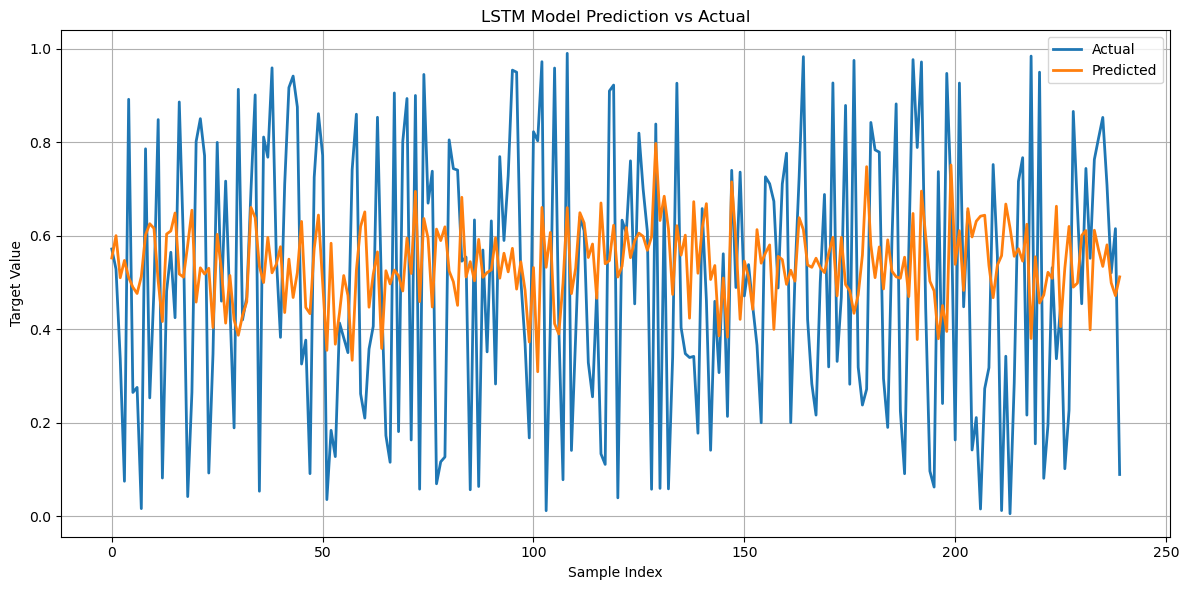

In [16]:

# Predict on test data
y_pred = model.predict(X_test)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', linewidth=2)
plt.plot(y_pred, label='Predicted', linewidth=2)
plt.title('LSTM Model Prediction vs Actual')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\vasil\AppData\Local\Temp\ipykernel_9724\3189604756.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=pd.to_datetime(data['close_time'].iloc[-1]), periods=future_days+1, freq='H')[1:]



📈 Forecasted Market Trends:
                     close_time         close          EMAF          EMAM  \
160  2025-01-08 12:59:59.999000  95192.430712  96654.009653  98248.879550   
161  2025-01-08 13:59:59.999000  95182.906035  96513.904547  98188.167203   
162  2025-01-08 14:59:59.999000  95194.695328  96388.265574  98128.890532   
163  2025-01-08 15:59:59.999000  95207.825448  96275.842705  98071.047659   
164  2025-01-08 16:59:59.999000  95181.467699  96171.616514  98013.828254   
165  2025-01-08 17:59:59.999000  95181.467946  96077.316650  97957.741912   
166  2025-01-08 18:59:59.999000  95208.668192  95994.588225  97903.304808   
167  2025-01-08 19:59:59.999000  95196.491521  95918.579016  97849.704545   
168  2025-01-08 20:59:59.999000  95177.937884  95848.041765  97796.798275   
169  2025-01-08 21:59:59.999000  95193.118401  95785.668111  97745.240257   

             EMAS MarketTrend  
160  97881.821690    Sideways  
161  97846.074463    Sideways  
162  97810.956858    Sidewa

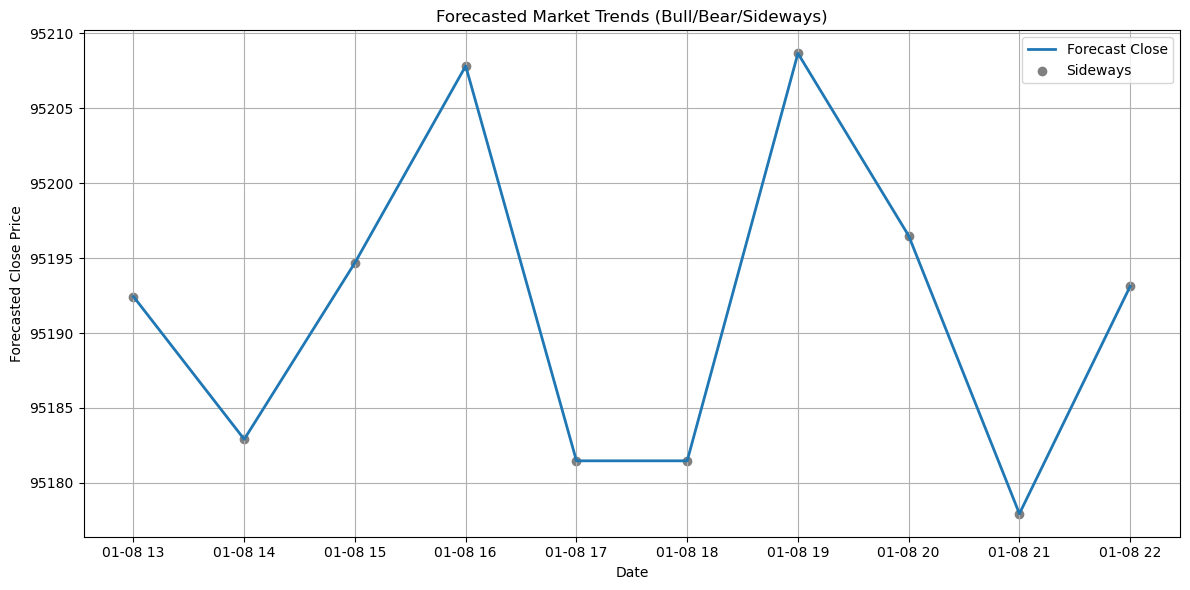

In [17]:
import pandas as pd
import numpy as np
import pandas_ta as ta

# --- Parameters ---
future_days = 10  # Number of future days to simulate
ema_short = 20
ema_mid = 100
ema_long = 150

# --- Clone last rows to simulate future ---
future_df = data.tail(ema_long + future_days).copy()  # Make sure EMAs have enough history

# --- Simulate future close prices (dummy forecast: repeat last close + noise) ---
last_close = future_df['close'].iloc[-1]
np.random.seed(42)
future_closes = [last_close + np.random.normal(0, 15) for _ in range(future_days)]

# --- Extend the dataframe ---
dates = pd.date_range(start=pd.to_datetime(data['close_time'].iloc[-1]), periods=future_days+1, freq='H')[1:]
future_data = pd.DataFrame({
    'close': future_closes,
    'close_time': dates
})
extended_df = pd.concat([future_df, future_data], ignore_index=True)

# --- Recalculate EMA indicators on the extended set ---
extended_df['EMAF'] = ta.ema(extended_df['close'], length=ema_short)
extended_df['EMAM'] = ta.ema(extended_df['close'], length=ema_mid)
extended_df['EMAS'] = ta.ema(extended_df['close'], length=ema_long)

# --- Trend classifier ---
def classify_trend(row):
    if row['EMAF'] > row['EMAM'] > row['EMAS']:
        return 'Bull'
    elif row['EMAF'] < row['EMAM'] < row['EMAS']:
        return 'Bear'
    else:
        return 'Sideways'

extended_df['MarketTrend'] = extended_df.apply(classify_trend, axis=1)

# --- Get only the forecasted part ---
forecast_trend = extended_df[['close_time', 'close', 'EMAF', 'EMAM', 'EMAS', 'MarketTrend']].tail(future_days)

# --- Show results ---
print("\n📈 Forecasted Market Trends:")
print(forecast_trend)

# --- Optional: Plot trends ---
import matplotlib.pyplot as plt
colors = {'Bull': 'green', 'Bear': 'red', 'Sideways': 'gray'}

plt.figure(figsize=(12, 6))
plt.plot(forecast_trend['close_time'], forecast_trend['close'], label='Forecast Close', linewidth=2)
for i, row in forecast_trend.iterrows():
    plt.scatter(row['close_time'], row['close'], color=colors[row['MarketTrend']], label=row['MarketTrend'] if i == forecast_trend.index[0] else "")
plt.title("Forecasted Market Trends (Bull/Bear/Sideways)")
plt.xlabel("Date")
plt.ylabel("Forecasted Close Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

# --- Parameters ---
backcandles = 30
future_days = [5, 7, 30]

# --- Features to Use ---
features = ['open', 'high', 'low', 'close', 'volume', 'RSI', 'EMAF', 'EMAM']

# --- Drop rows with NaNs just to be safe ---
data = data.dropna(subset=features + ['TargetClass', 'TargetNextClose'])

# --- Normalize the features ---
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

# --- Create sequences and targets ---
X = []
y_class = []
y_5d = []
y_7d = []
y_30d = []

for i in range(backcandles, len(scaled_df) - max(future_days)):
    X.append(scaled_data[i-backcandles:i])
    y_class.append(data['TargetClass'].iloc[i])  # For bull/bear trend
    y_5d.append(data['close'].iloc[i + 5])
    y_7d.append(data['close'].iloc[i + 7])
    y_30d.append(data['close'].iloc[i + 30])

X = np.array(X)
y_class = np.array(y_class)
y_5d = np.array(y_5d)
y_7d = np.array(y_7d)
y_30d = np.array(y_30d)

# --- Split into training and test sets ---
X_train, X_test, y5_train, y5_test = train_test_split(X, y_5d, test_size=0.2, shuffle=False)
_, _, y7_train, y7_test = train_test_split(X, y_7d, test_size=0.2, shuffle=False)
_, _, y30_train, y30_test = train_test_split(X, y_30d, test_size=0.2, shuffle=False)

# --- Define model for price prediction ---
def build_model():
    model = Sequential()
    model.add(LSTM(150, input_shape=(backcandles, len(features))))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# --- Train models ---
model_5d = build_model()
model_7d = build_model()
model_30d = build_model()

model_5d.fit(X_train, y5_train, epochs=15, batch_size=16, validation_split=0.1)
model_7d.fit(X_train, y7_train, epochs=15, batch_size=16, validation_split=0.1)
model_30d.fit(X_train, y30_train, epochs=15, batch_size=16, validation_split=0.1)

# --- Predictions ---
pred_5d = model_5d.predict(X_test)
pred_7d = model_7d.predict(X_test)
pred_30d = model_30d.predict(X_test)



\\?\C:\Users\vasil\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 661581504.0000 - val_loss: 639076672.0000
Epoch 2/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 47s 16ms/step - loss: 646190400.0000 - val_loss: 619448128.0000
Epoch 3/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 631238848.0000 - val_loss: 600090048.0000
Epoch 4/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 616531456.0000 - val_loss: 581043520.0000
Epoch 5/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 45s 16ms/step - loss: 602150336.0000 - val_loss: 562134208.0000
Epoch 6/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 587921152.0000 - val_loss: 543506368.0000
Epoch 7/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 574034432.0000 - val_loss: 525248576.0000
Epoch 8/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 560487552.0000 - val_loss: 507212960.0000
Epoch 9/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - loss: 547187136.0000 - val_loss: 489536544.0000
Epoch 10/15
2896/2896 ━━━━━━━━━━━━━━━━━━━━ 47s

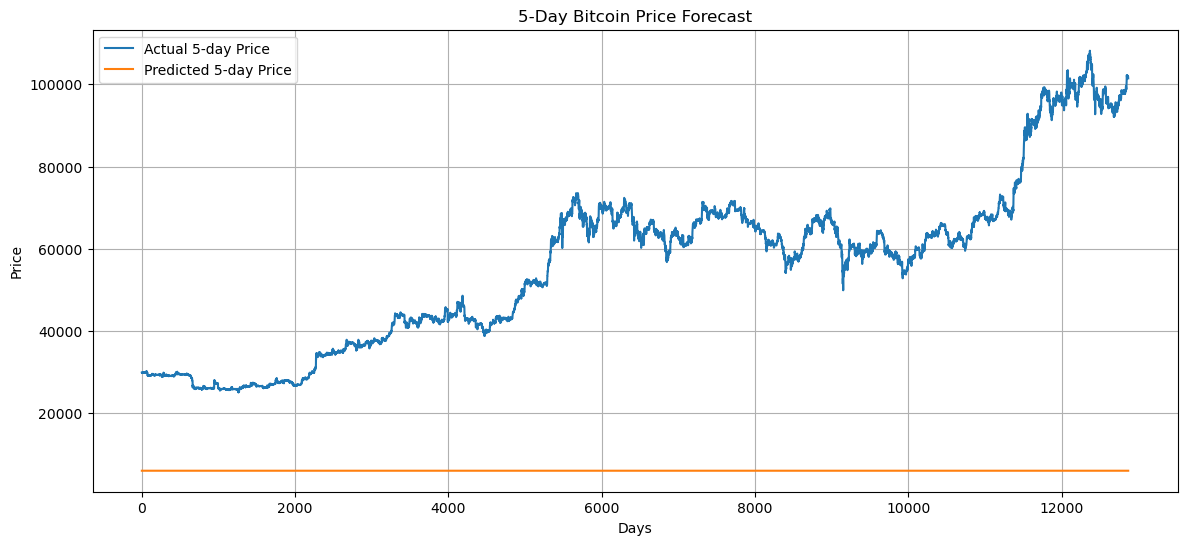

In [20]:

# --- Plotting predictions ---
plt.figure(figsize=(14, 6))
plt.plot(y5_test, label='Actual 5-day Price')
plt.plot(pred_5d, label='Predicted 5-day Price')
plt.title('5-Day Bitcoin Price Forecast')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

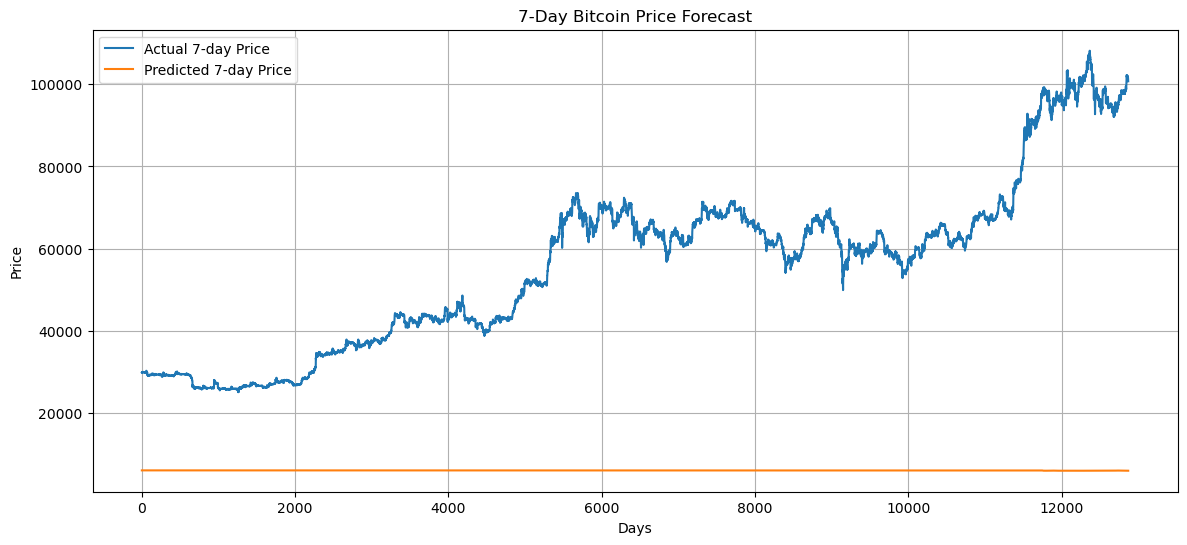

In [21]:

plt.figure(figsize=(14, 6))
plt.plot(y7_test, label='Actual 7-day Price')
plt.plot(pred_7d, label='Predicted 7-day Price')
plt.title('7-Day Bitcoin Price Forecast')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


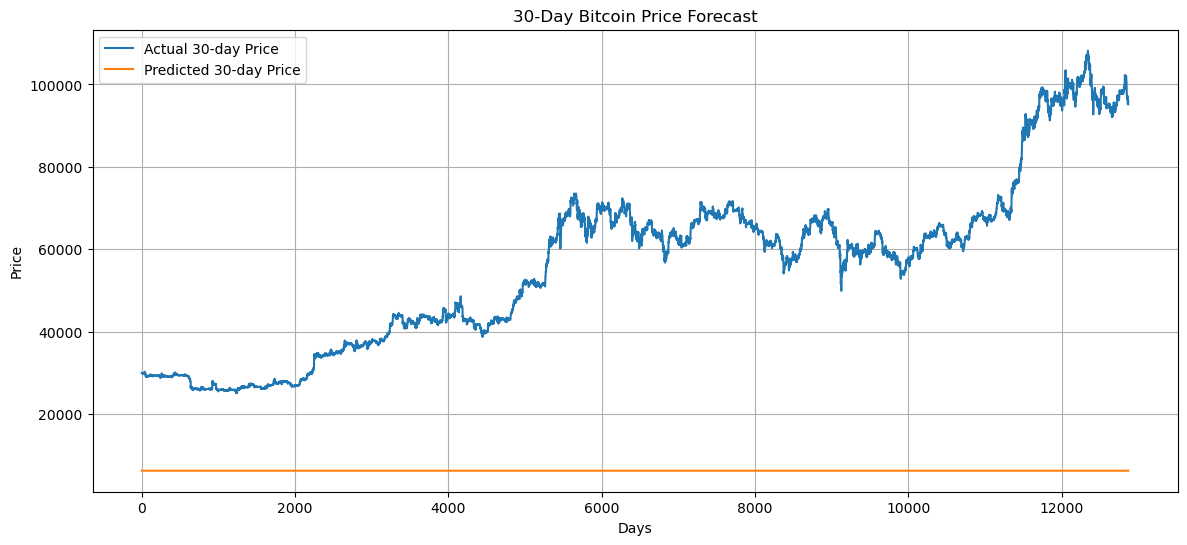

In [22]:

plt.figure(figsize=(14, 6))
plt.plot(y30_test, label='Actual 30-day Price')
plt.plot(pred_30d, label='Predicted 30-day Price')
plt.title('30-Day Bitcoin Price Forecast')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

### 